In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2RiaGFnaWEvTGlicmFyeS9DbG91ZFN0b3JhZ2UvRHJvcGJveC1DU1VGdWxsZXJ0b24vRGl2IEJoYWdpYS9UZWFjaGluZy9lY29uNTAyL3ByYWN0aWNlLXByb2JsZW1z'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap.py": 1764689462.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap_external.py": 1764689462.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/codecs.py": 1764689446.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/aliases.py": 1764689466.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/cp437.py": 1764689466.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/__init__.py": 1764689466.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/utf_8.py": 1764689467.0, "/Library/Developer/CommandLineT

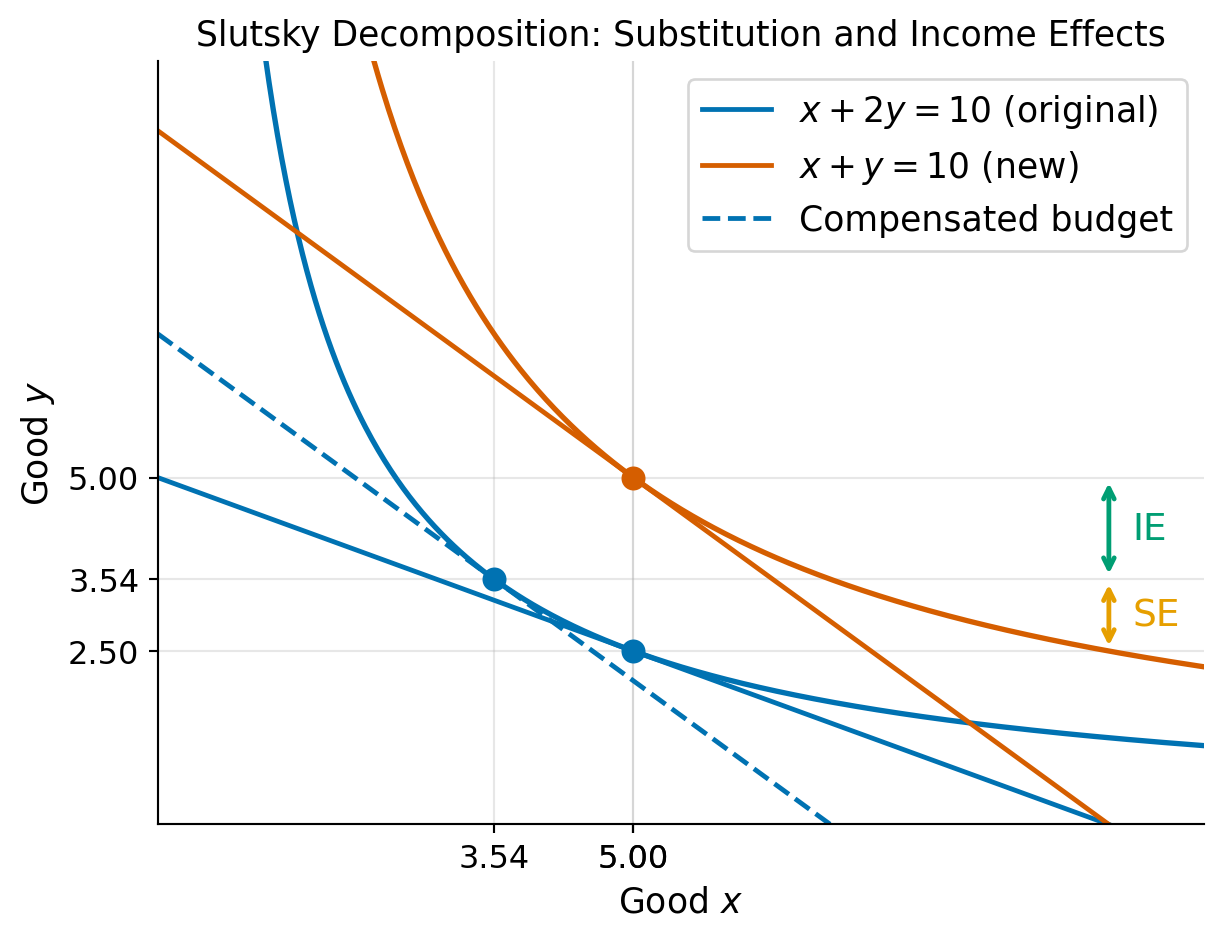

In [2]:
#| echo: false
#| fig-align: center

import matplotlib.pyplot as plt
import numpy as np

# Colorblind-friendly palette
CB_BLUE  = '#0072B2'
CB_RED   = '#D55E00'
CB_GREEN = '#009E73'
CB_ORANGE = '#E69F00'


# ── Parameters ─────────────────────────────────────────────────
px, py0, py1, m = 1, 2, 1, 10

# Key points
xA, yA = 5.0, 2.5                         # original optimum A
xC, yC = 5.0, 5.0                         # new optimum C
u0 = xA * yA                              # = 12.5
xB = np.sqrt(py1 / px * u0)               # Hicksian demand for x at new prices
yB = np.sqrt(px / py1 * u0)               # Hicksian demand for y at new prices  ≈ 3.54
e_comp = px * xB + py1 * yB               # compensated expenditure ≈ 7.07

# ── Figure ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5))

x = np.linspace(0.0001, 11, 500)

# Indifference curves
ax.plot(x, u0 / x, color=CB_BLUE, lw=2)
ax.plot(x, (xC * yC) / x, color=CB_RED, lw=2)

# Budget lines
ax.plot(x, (m - px * x) / py0, color=CB_BLUE, lw=1.8, ls='-',
        label=r'$x + 2y = 10$ (original)')
ax.plot(x, (m - px * x) / py1, color=CB_RED, lw=1.8, ls='-',
        label=r'$x + y = 10$ (new)')
ax.plot(x, (e_comp - px * x) / py1, color=CB_BLUE, lw=1.8, ls='--',
        label=r'Compensated budget')

# Optimal points
ax.plot(xA, yA, 'o', color=CB_BLUE, ms=8, zorder=5)
ax.plot(xB, yB, 'o', color=CB_BLUE,  ms=8, zorder=5)
ax.plot(xC, yC, 'o', color=CB_RED, ms=8, zorder=5)

# ── Decomposition arrows on the right margin ────────────────────
x_arr = 10.0  # x-position for arrows
ax.annotate('', xy=(x_arr, yB), xytext=(x_arr, yA),
            arrowprops=dict(arrowstyle='<->', color=CB_ORANGE, lw=1.8))
ax.text(x_arr + 0.25, (yA + yB) / 2, 'SE', va='center', fontsize=14, color=CB_ORANGE)

ax.annotate('', xy=(x_arr, yC), xytext=(x_arr, yB),
            arrowprops=dict(arrowstyle='<->', color=CB_GREEN, lw=1.8))
ax.text(x_arr + 0.25, (yB + yC) / 2, 'IE', va='center', fontsize=14, color=CB_GREEN)

# ── Formatting ──────────────────────────────────────────────────
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)
ax.set_xticks([xA, xB, xC])
ax.set_yticks([yA, yB, yC])
ax.set_xticklabels([f'{xA:.2f}', f'{xB:.2f}', f'{xC:.2f}'], size=12)
ax.set_yticklabels([f'{yA:.2f}', f'{yB:.2f}', f'{yC:.2f}'], size=12)
ax.set_xlabel('Good $x$', fontsize=13)
ax.set_ylabel('Good $y$', fontsize=13)
ax.set_title('Slutsky Decomposition: Substitution and Income Effects', fontsize=13)
ax.legend(fontsize=13, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()